In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=0.72882357/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

Enter measurements for species

In [14]:
logN_dict = {'HI':'16.67, -0.02, +0.02',
            'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            'NII':'<13.5',
            'NIII':'<12.8',
            'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'OVI':'14.17, -0.07, +0.07',
            'NeVIII':'<13.3',
            'MgII':'<11.0',
            'AlIII':'<11.5',
            'SiII':'<12.3',
            'SiIII':'<12.3',
            'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',
            'SVI':'<12.8',
            'FeII':'<11.4'}

Try out a new solution including sub-solar [C/O]

In [15]:
logN_HI_test = 16.67
log_hdens_test =  -2.9
log_metals_test = -2.6

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, log_metals_test, 
                                     species_logN_interp, {'C':-0.45})

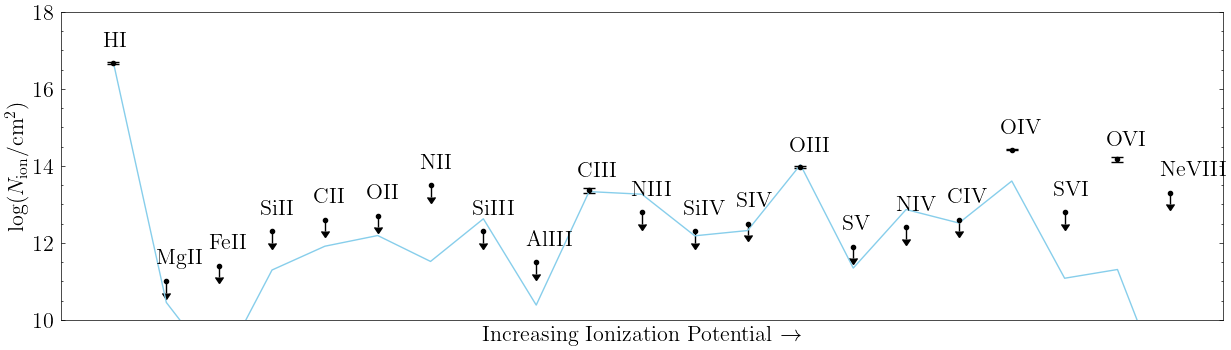

In [17]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

Get column density ratios

In [18]:
gen_logN_ratio_str(logN_dict['CIII'], logN_dict['CIV'])

'>0.76, 0.16'

In [19]:
logN_ratio_dict = {#'OIV/OIII': '0.45, -0.04, 0.04',
                   'OIII/OII':'>1.3, 0.1',
                   'OIII/SIV': '>1.5, 0.1',
                   'OIII/SV': '>2.1, 0.1',
                   'CIII/CII':'>0.8, 0.2',
                   'CIII/CIV': '>0.8, 0.2'}

Generate predicted column density ratios

(0.0, 5.0)

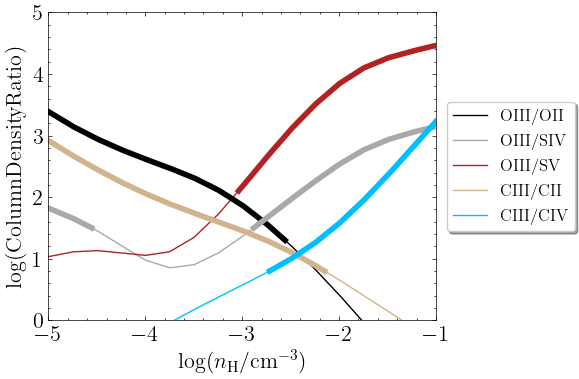

In [20]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict, 
                logN_HI_ref=12.5, log_metals_ref=-2.5)

ax.set_xlim(-5, -1)
ax.set_ylim(-0, 5)

# Fit gas density

In [21]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [22]:
logN_ratio_dict

{'OIII/OII': '>1.3, 0.1',
 'OIII/SIV': '>1.5, 0.1',
 'OIII/SV': '>2.1, 0.1',
 'CIII/CII': '>0.8, 0.2',
 'CIII/CIV': '>0.8, 0.2'}

In [23]:
#pos = np.array(-2.6) + 1e-4 * np.random.randn(500, 1)
#nwalkers, ndim = pos.shape

In [24]:
#sampler = emcee.EnsembleSampler(
#    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
#)

In [25]:
#sampler.run_mcmc(pos, 500, progress=True);

In [26]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_op.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_op.csv')

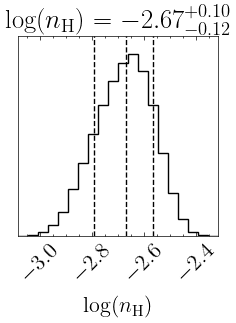

In [27]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [28]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [29]:
logN_offset = 13.97-np.mean(species_logN_interp['O+2'](grid_points_hdens))

Calculate the C/O ratio

In [30]:
logN_CIII_obs = np.random.normal(loc=13.36, scale=0.07, size=len(flat_samples_hdens))

In [31]:
C_O_dist_CIII = logN_CIII_obs-(logN_offset+species_logN_interp['C+2'](grid_points_hdens))
C_O_dist = C_O_dist_CIII

In [32]:
get_quantiles(C_O_dist)

-0.46 -0.14 0.13


Plot models

In [33]:
logN_dict = {#'HI':'16.67, -0.02, +0.02',
            'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            #'NII':'<13.5',
            #'NIII':'<12.8',
            #'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            #'OVI':'14.17, -0.07, +0.07',
            #'NeVIII':'<13.3',
            'MgII':'<11.0',
            #'AlIII':'<11.5',
            #'SiII':'<12.3',
            #'SiIII':'<12.3',
            #'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',}
            #'SVI':'<12.8',
            #'FeII':'<11.4'}

In [34]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

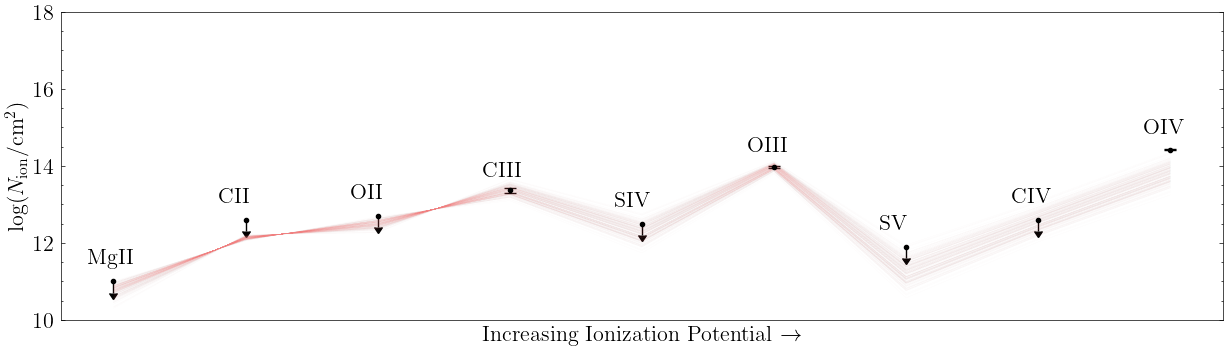

In [35]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp, {'C': np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='lightcoral', lw=.2, alpha=.05)

Plot cloud sizes

In [36]:
l_dist = np.array([get_cloud_size(16.67, log_hdens, species_logN_interp) for log_hdens in flat_samples_hdens['log_hdens']])

(array([2.5210e+03, 1.8954e+04, 3.1362e+04, 3.0765e+04, 2.5251e+04,
        1.9711e+04, 1.5261e+04, 1.2010e+04, 9.4960e+03, 7.3880e+03,
        5.8300e+03, 4.5520e+03, 3.6350e+03, 2.9510e+03, 2.2990e+03,
        1.8280e+03, 1.3870e+03, 1.0860e+03, 7.8200e+02, 6.6400e+02,
        4.9200e+02, 4.2800e+02, 3.3000e+02, 2.1100e+02, 1.9600e+02,
        1.5800e+02, 1.0700e+02, 9.2000e+01, 4.2000e+01, 4.4000e+01,
        4.1000e+01, 4.2000e+01, 2.5000e+01, 7.0000e+00, 1.0000e+01,
        4.0000e+00, 2.0000e+00, 1.5000e+01, 1.0000e+01, 7.0000e+00,
        0.0000e+00, 0.0000e+00, 3.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([ 1.69863098,  3.5192453 ,  5.33985962,  7.16047393,  8.98108825,
        10.80170257, 12.62231688, 14.4429312 , 16.26354552, 18.08415983,
        19.90477415, 21.72538847, 23.54600279, 25.3666171 , 27.18723142,
        29.00784574, 30.82846005, 32.64907437, 34.46968869, 36.290303  ,
        38.11091732, 39.93153164, 41.75214595, 43.57276027, 45.39337459,
        47.2139889 , 

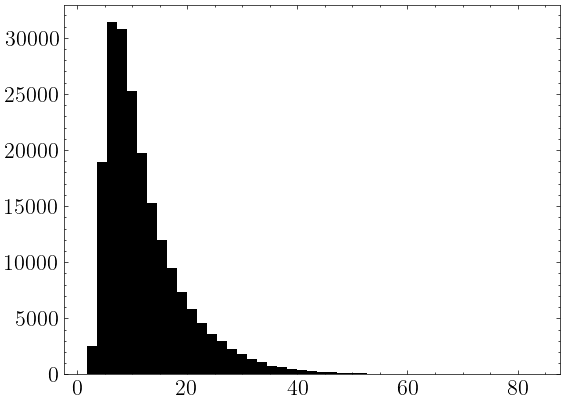

In [37]:
plt.hist(l_dist, bins=45)

# Two-phase solution

Let's do a high density phase, varying all three parameters. And a low density phase, fixed density, vary HI and metallicity.

In [38]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = log_prior_tp(params, species_logN_interp)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_tp(params, logN_dict, species_logN_interp)

Plot some solutions

In [39]:
logN_dict = {'HI':'16.67, -0.02, +0.02',
            #'CII':'<12.6',
            #'CIII':'13.36, -0.07, +0.07',
            #'CIV':'<12.6',
            #'NII':'<13.5',
            #'NIII':'<12.8',
            #'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'<14.42',
            'OVI':'<14.17',
            #'NeVIII':'<13.3',
            'MgII':'<11.0',
            #'AlIII':'<11.5',
            #'SiII':'<12.3',
            #'SiIII':'<12.3',
            #'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',}
            #'SVI':'<12.8',
            #'FeII':'<11.4'}

In [70]:
logN_HI_p1_test = 16.5
log_hdens_p1_test = -1
log_metals_p1_test = -2

logN_HI_p2_test = 15.5
log_hdens_p2_test = -2.7
log_metals_p2_test = -1

In [71]:
logN_species_test_p1 = np.array(predict_col_dens(logN_dict, 
                                                 logN_HI_p1_test, 
                                                 log_hdens_p1_test, 
                                                 log_metals_p1_test, 
                                                 species_logN_interp))

logN_species_test_p2 = np.array(predict_col_dens(logN_dict, 
                                                 logN_HI_p2_test, 
                                                 log_hdens_p2_test, 
                                                 log_metals_p2_test, 
                                                 species_logN_interp))


logN_species_test = np.log10(10**logN_species_test_p1 + 10**logN_species_test_p2)

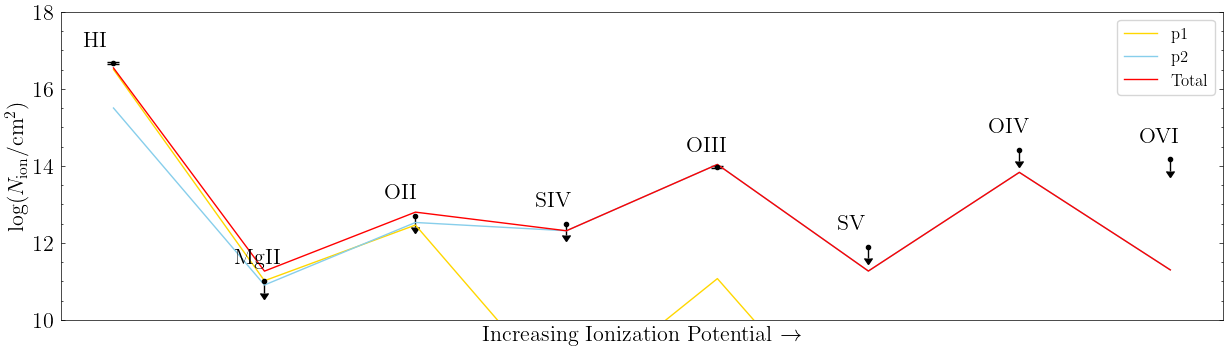

In [72]:
fig, ax = plot_column_densities_obs(logN_dict)

ax.plot(np.arange(len(logN_species_test)), logN_species_test_p1, color='gold', label='p1')
ax.plot(np.arange(len(logN_species_test)), logN_species_test_p2, color='skyblue', label='p2')
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='red', label='Total')

ax.legend()

In [73]:
pos = np.array([logN_HI_p1_test, log_hdens_p1_test, log_metals_p1_test,
                logN_HI_p2_test, log_hdens_p2_test, log_metals_p2_test]) + 1e-4 * np.random.randn(500, 6)
nwalkers, ndim = pos.shape

In [74]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict, species_logN_interp)
)

In [75]:
sampler.run_mcmc(pos, 500, progress=True);

  8%|███▎                                      | 39/500 [01:03<12:31,  1.63s/it]/Users/thepoetoftwilight/Documents/CUBS/Code/cloudy_fitting/cloudy_fit_lib.py:1421: RuntimeWarning: divide by zero encountered in log
  ll += np.log(integrate.simpson(x=y_range, y=np.exp(-.5*(y_range-y_bar)**2/sig_y**2)))
100%|█████████████████████████████████████████| 500/500 [10:26<00:00,  1.25s/it]


In [76]:
flat_samples_tp = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logN_HI_p1', 'log_hdens_p1', 'log_metals_p1',
                                         'logN_HI_p2', 'log_hdens_p2', 'log_metals_p2'])
flat_samples_tp.to_csv(savedir+'tp.csv', index=False)

#flat_samples_tp = pd.read_csv(savedir+'tp.csv')

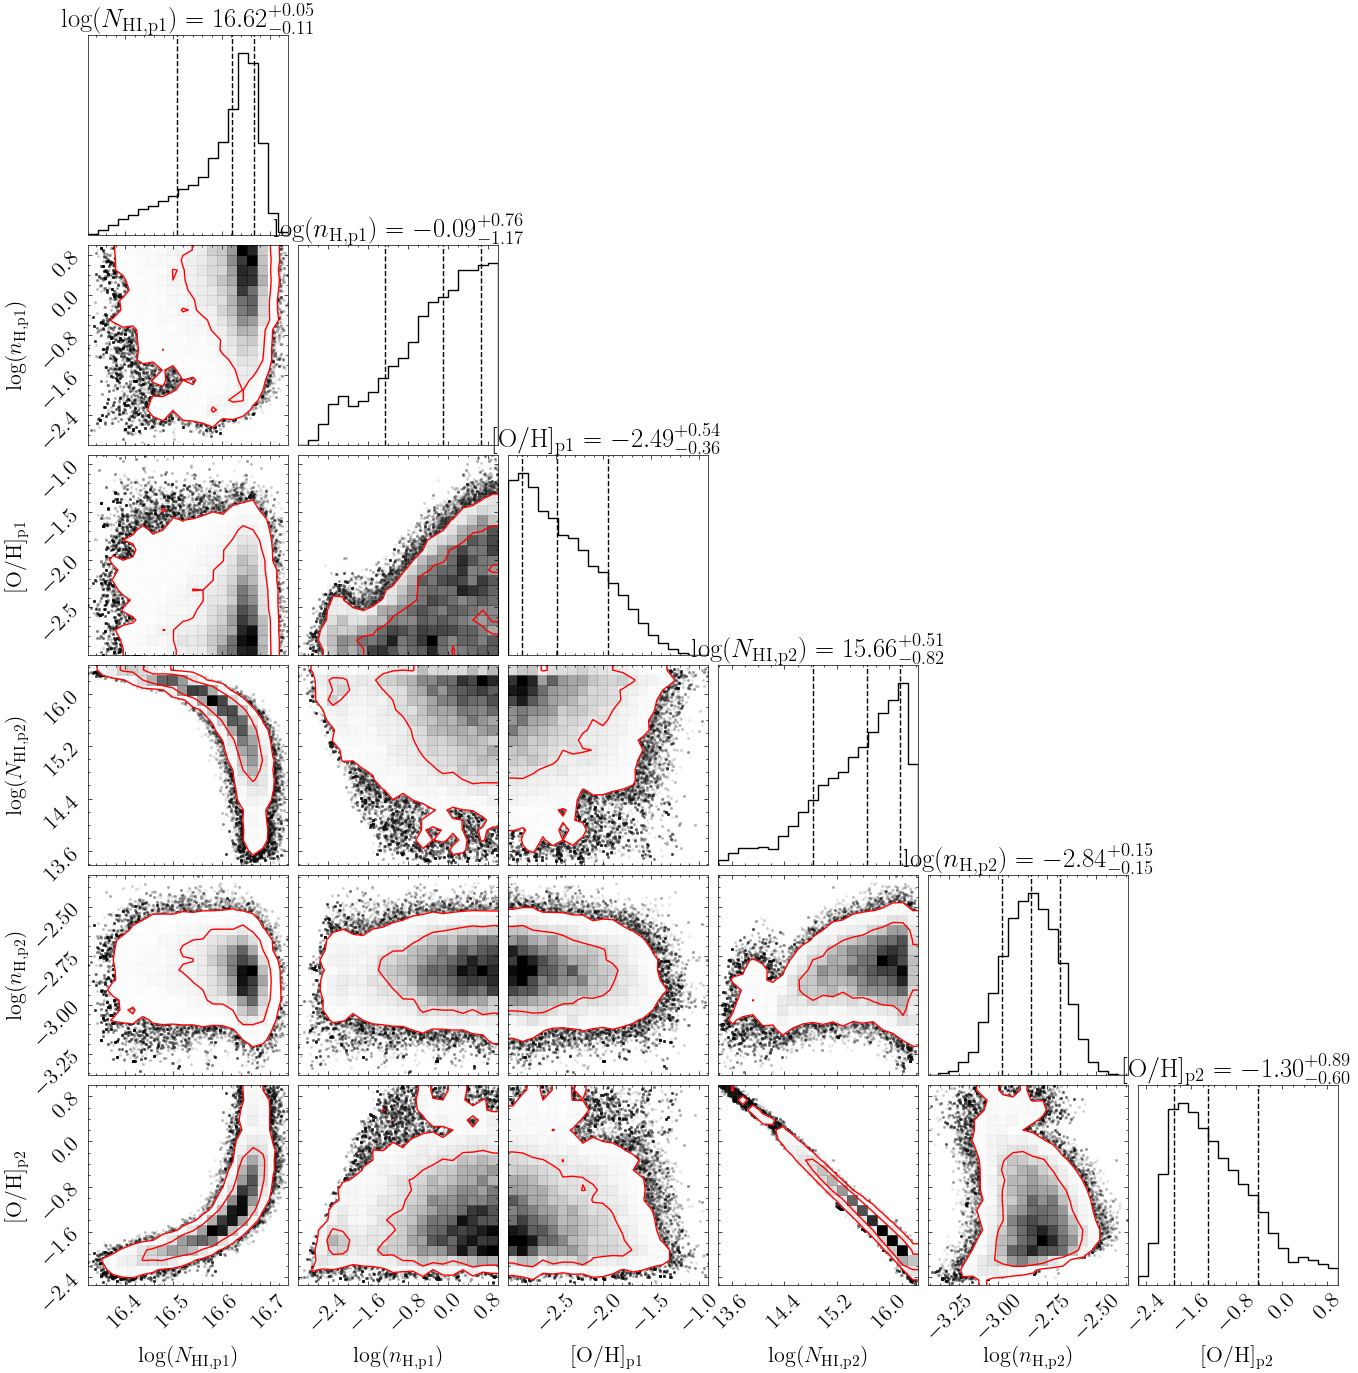

In [77]:
fig = corner.corner(
    flat_samples_tp, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(N_\mathrm{HI, p1})$', r'$\log(n_\mathrm{H, p1})$', r'$[\mathrm{O/H}]_{\mathrm{p1}}$',
            r'$\log(N_\mathrm{HI, p2})$', r'$\log(n_\mathrm{H, p2})$', r'$[\mathrm{O/H}]_{\mathrm{p2}}$',], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Get cloud sizes

In [78]:
l_hi_dist = np.zeros(len(flat_samples_tp))

for i in range(len(flat_samples_tp)):
    
    flat_samples_row = flat_samples_tp.iloc[i]

    l_hi_dist[i] = get_cloud_size(flat_samples_row['logN_HI_p1'], flat_samples_row['log_hdens_p1'], 
                                    species_logN_interp, flat_samples_row['log_metals_p1'])

In [79]:
l_lo_dist = np.zeros(len(flat_samples_tp))

for i in range(len(flat_samples_tp)):
    
    flat_samples_row = flat_samples_tp.iloc[i]

    l_lo_dist[i] = get_cloud_size(flat_samples_row['logN_HI_p2'], flat_samples_row['log_hdens_p2'], 
                                    species_logN_interp, flat_samples_row['log_metals_p2'])

(0.0, 1000.0)

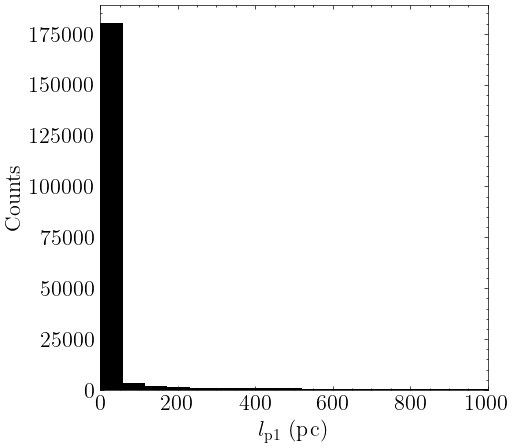

In [91]:
fig, ax = plt.subplots(1, figsize=(5,5))

ax.hist(1000*l_hi_dist, bins=500)

ax.set_xlabel(r'$l_{\mathrm{p1}}$ (pc)')
ax.set_ylabel('Counts')

ax.set_xlim(0,1000)

In [81]:
1000*np.median(l_hi_dist)

0.060541244708620365

Text(0, 0.5, 'Counts')

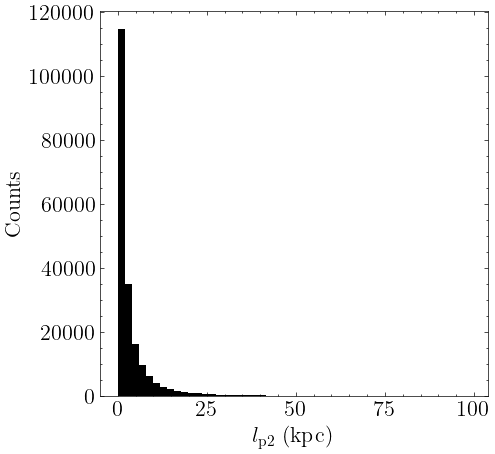

In [82]:
fig, ax = plt.subplots(1, figsize=(5,5))

ax.hist(l_lo_dist, bins=50)

ax.set_xlabel(r'$l_{\mathrm{p2}}$ (kpc)')
ax.set_ylabel('Counts')

In [83]:
np.median(l_lo_dist)

1.4583536218765865

Text(0, 0.5, '$l_{\\mathrm{p2}}$ (kpc)')

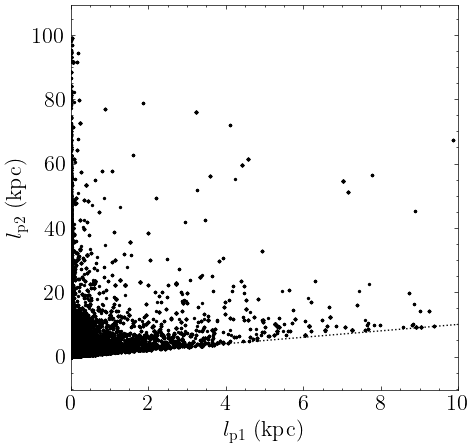

In [84]:
fig, ax = plt.subplots(1, figsize=(5,5))
ax.scatter(l_hi_dist, l_lo_dist, s=2)

lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]

# now plot both limits against eachother
ax.plot(lims, lims, linestyle=':')

ax.set_xlim(0, 10)

ax.set_xlabel(r'$l_{\mathrm{p1}}$ (kpc)')
ax.set_ylabel(r'$l_{\mathrm{p2}}$ (kpc)')

Now plot the best models

In [85]:
logN_dict = {'HI':'16.67, -0.02, +0.02',
            #'CII':'<12.6',
            #'CIII':'13.36, -0.07, +0.07',
            #'CIV':'<12.6',
            #'NII':'<13.5',
            #'NIII':'<12.8',
            #'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'<14.42',
            'OVI':'<14.17',
            #'NeVIII':'<13.3',
            'MgII':'<11.0',
            #'AlIII':'<11.5',
            #'SiII':'<12.3',
            #'SiIII':'<12.3',
            #'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',}
            #'SVI':'<12.8',
            #'FeII':'<11.4'}

In [86]:
sample_indices_tp = np.random.randint(low=0, high=len(flat_samples_tp), size=200)

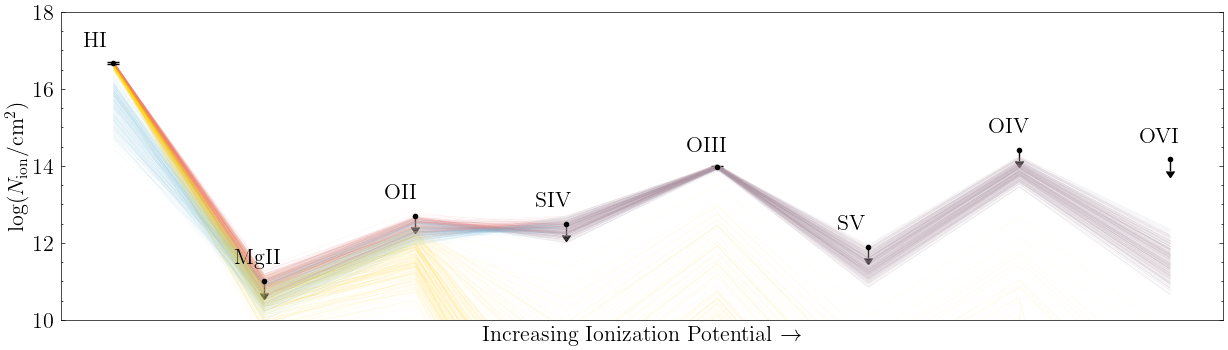

In [87]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_tp)):
    
    idx = sample_indices_tp[i]
    flat_samples_row = flat_samples_tp.iloc[i]
    
    logN_HI_p1 = flat_samples_row['logN_HI_p1']
    log_hdens_p1 = flat_samples_row['log_hdens_p1']
    log_metals_p1 = flat_samples_row['log_metals_p1']

    logN_species_test_p1 = np.array(predict_col_dens(logN_dict, logN_HI_p1, log_hdens_p1, 
                                         log_metals_p1, species_logN_interp))
    
    logN_HI_p2 = flat_samples_row['logN_HI_p2']
    log_hdens_p2 = flat_samples_row['log_hdens_p2']
    log_metals_p2 = flat_samples_row['log_metals_p2']
    
    logN_species_test_p2 = np.array(predict_col_dens(logN_dict, logN_HI_p2, log_hdens_p2, 
                                         log_metals_p2, species_logN_interp))
    
    logN_species_test = np.log10(10**logN_species_test_p1 + 10**logN_species_test_p2)
        
    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test_p1, color='gold', lw=.2, alpha=.15)
    ax.plot(np.arange(len(logN_species_test)), logN_species_test_p2, color='skyblue', lw=.2, alpha=.15)

    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.15)

In [88]:
1000*get_cloud_size(12, 1, species_logN_interp)

4.729898965319998e-08

# Low density phase

In [156]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [157]:
logN_dict = {'HI':'16.67, -0.02, +0.02',
            'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            'NII':'<13.5',
            'NIII':'<12.8',
            'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'<13.97',
            'OIV':'14.42, -0.02, +0.02',
            'OVI':'<14.17',
            'NeVIII':'<13.3',
            'MgII':'<11.0',
            'AlIII':'<11.5',
            'SiII':'<12.3',
            'SiIII':'<12.3',
            'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',
            'SVI':'<12.8',
            'FeII':'<11.4'}

Get column density ratios

In [158]:
gen_logN_ratio_str(logN_dict['NeVIII'], logN_dict['OIV'])

'<-1.12, 0.14'

In [159]:
logN_ratio_dict = {#'SVI/OIV': '<-1.6, 0.1',
                   'OVI/OIV': '<-0.2, 0.2',
                   'OIII/OIV': '<-0.4, 0.2',
                   'NeVIII/OIV': '<-1.1, 0.2'
                   #'SV/OIV': '<-2.5, 0.1'
                  }

(-5.0, 5.0)

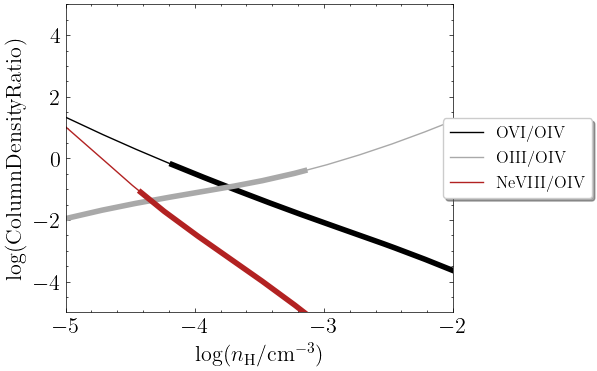

In [160]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -2)
ax.set_ylim(-5, 5)

In [161]:
#pos = np.array(-3.8) + 1e-6 * np.random.randn(500, 1)
#nwalkers, ndim = pos.shape

In [162]:
#sampler = emcee.EnsembleSampler(
#    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
#)

In [163]:
#sampler.run_mcmc(pos, 500, progress=True);

In [164]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_lo.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_lo.csv')

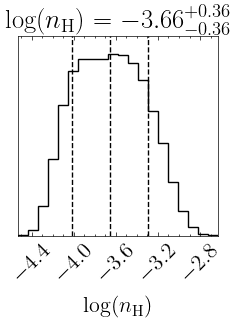

In [165]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [166]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [167]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

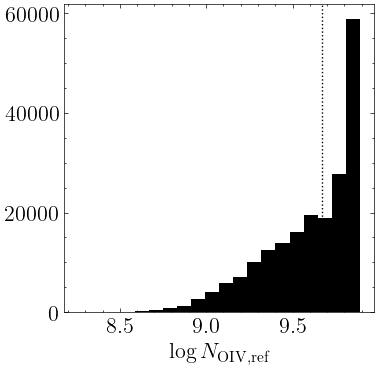

In [168]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{OIII, ref}}$')

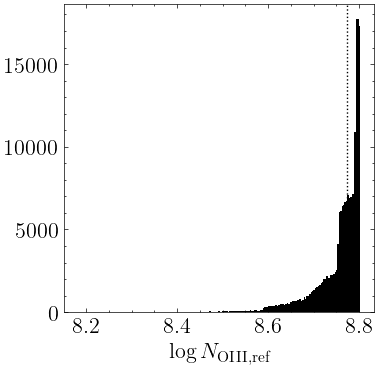

In [169]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['O+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{CIII, ref}}$')

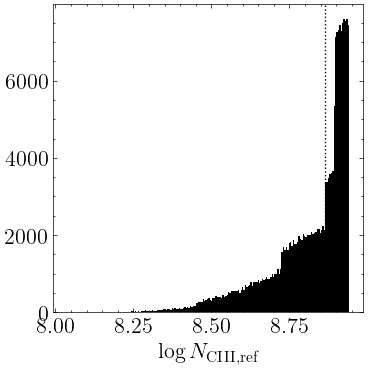

In [170]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['C+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['C+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{CIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [171]:
logN_offset = 14.42-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [172]:
logN_offset

4.750787236117658

Get yields

In [173]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

13.52 -0.06 0.02


In [174]:
get_quantiles(logN_offset+species_logN_interp['C+2'](grid_points_hdens))

13.62 -0.18 0.06


In [175]:
12.6-13.6

-1.0

Plot models

In [176]:
logN_dict = {#'HI':'16.67, -0.02, +0.02',
            #'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            #'NII':'<13.5',
            #'NIII':'<12.8',
            #'NIV':'<12.4',
            #'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'OVI':'14.17, -0.07, +0.07',
            'NeVIII':'<13.3',
            #'MgII':'<11.0',
            #'AlIII':'<11.5',
            #'SiII':'<12.3',
            #'SiIII':'<12.3',
            #'SiIV':'<12.3',
            #'SIV':'<12.5',
            #'SV':'<11.9',
            'SVI':'<12.8',}
            #'FeII':'<11.4'}

In [177]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

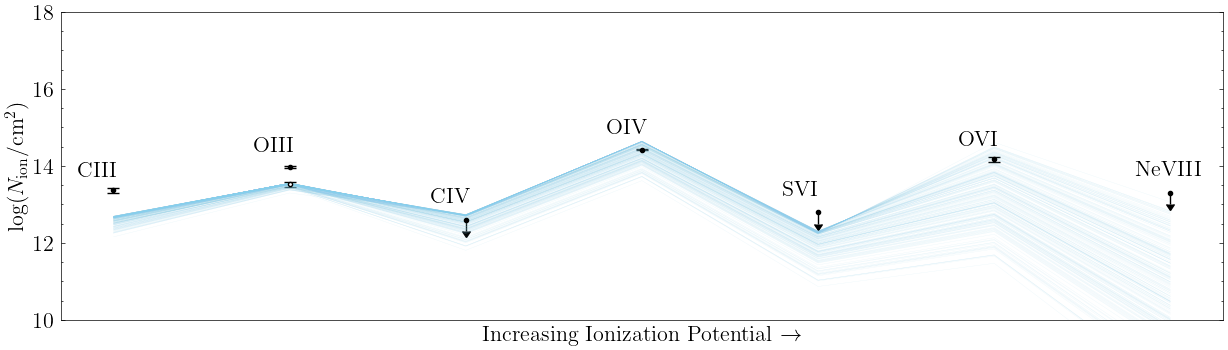

In [178]:
fig, ax = plot_column_densities_obs(logN_dict)

ax.errorbar(x=1, y=13.52, yerr=0.06, color='black', linestyle='None', mfc='white',
        fmt='o', markersize=3, capsize=4)

#ax.errorbar(x=1, y=13.98, yerr=0.08, color='black', linestyle='None', mfc='white',
#        fmt='o', markersize=3, capsize=4)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp, {'C': -1})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)

Calculate residual for OIII

In [179]:
logN_OIII_tot = np.random.normal(loc=13.97, scale=0.03, size=1000)
logN_OIII_lo_dens = np.random.normal(loc=13.52, scale=0.06, size=1000)
logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)

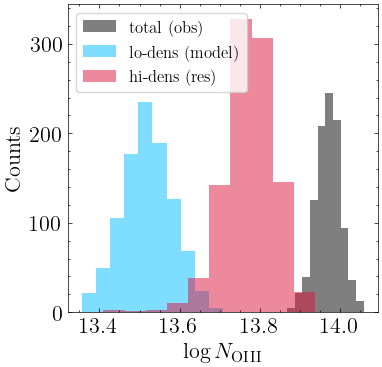

In [180]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_OIII_tot, label='total (obs)', alpha=0.5)
ax.hist(logN_OIII_lo_dens, label='lo-dens (model)', alpha=0.5)
ax.hist(logN_OIII_hi_dens, label='hi-dens (res)', alpha=0.5)

ax.set_xlabel(r'$\log N_{\mathrm{OIII}}$')
ax.set_ylabel('Counts')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [181]:
logN_OIII_hi_dens_clean = logN_OIII_hi_dens[~np.isnan(logN_OIII_hi_dens)]

In [182]:
get_quantiles(logN_OIII_hi_dens_clean)

13.78 -0.06 0.06


# Fit high density phase

In [183]:
logN_dict = {#'HI':'16.67, -0.02, +0.02',
            'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            #'NII':'<13.5',
            #'NIII':'<12.8',
            #'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.78, -0.06, +0.06',
            'OIV':'<14.42',
            #'OVI':'14.17, -0.07, +0.07',
            #'NeVIII':'<13.3',
            'MgII':'<11.0',
            #'AlIII':'<11.5',
            #'SiII':'<12.3',
            #'SiIII':'<12.3',
            #'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',}
            #'SVI':'<12.8',}
            #'FeII':'<11.4'}

Get column density ratios

In [184]:
gen_logN_ratio_str(logN_dict['CII'], logN_dict['CIII'])

'<-0.76, 0.16'

In [185]:
logN_ratio_dict = {'CIV/CIII': '<-0.8, 0.2',
                   'CII/CIII': '<-0.8, 0.2',
                    'SV/OIII': '<-1.9, 0.2',
                   'SIV/OIII': '<-1.3, 0.2',
                   'OII/OIII': '<-1.1, 0.2',
                   'MgII/OIII': '<-2.8, 0.2',
                   'OIV/OIII': '<0.6, 0.2'
                  }

(-5.0, 5.0)

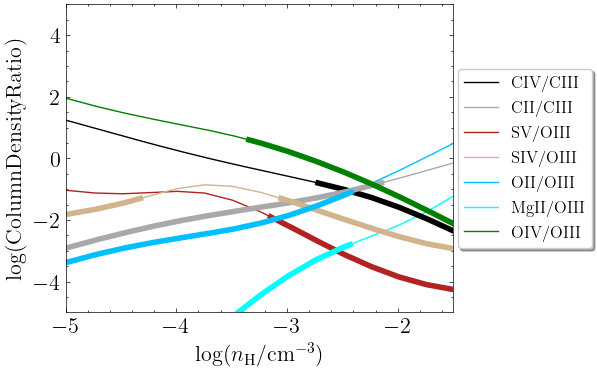

In [186]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

In [187]:
pos = np.array(-2.6) + 1e-6 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [188]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [189]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [11:26<00:00,  1.37s/it]


In [190]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_hi.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_hi.csv')

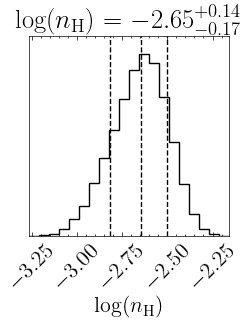

In [191]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [192]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [193]:
logN_offset = 13.78-np.median(species_logN_interp['O+2'](grid_points_hdens))

In [194]:
logN_offset

5.258877730223148

Calculate the C/O ratio

In [195]:
logN_CIII_obs = np.random.normal(loc=13.36, scale=0.07, size=len(flat_samples_hdens))

In [196]:
C_O_dist_CIII = logN_CIII_obs-(logN_offset+species_logN_interp['C+2'](grid_points_hdens))
C_O_dist = C_O_dist_CIII

In [197]:
get_quantiles(C_O_dist)

-0.26 -0.18 0.17


Plot models

In [198]:
logN_dict = {#'HI':'16.67, -0.02, +0.02',
            'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            #'NII':'<13.5',
            #'NIII':'<12.8',
            #'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.78, -0.06, +0.06',
            'OIV':'<14.42',
            #'OVI':'14.17, -0.07, +0.07',
            #'NeVIII':'<13.3',
            'MgII':'<11.0',
            #'AlIII':'<11.5',
            #'SiII':'<12.3',
            #'SiIII':'<12.3',
            #'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',}
            #'SVI':'<12.8',}
            #'FeII':'<11.4'}

In [199]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

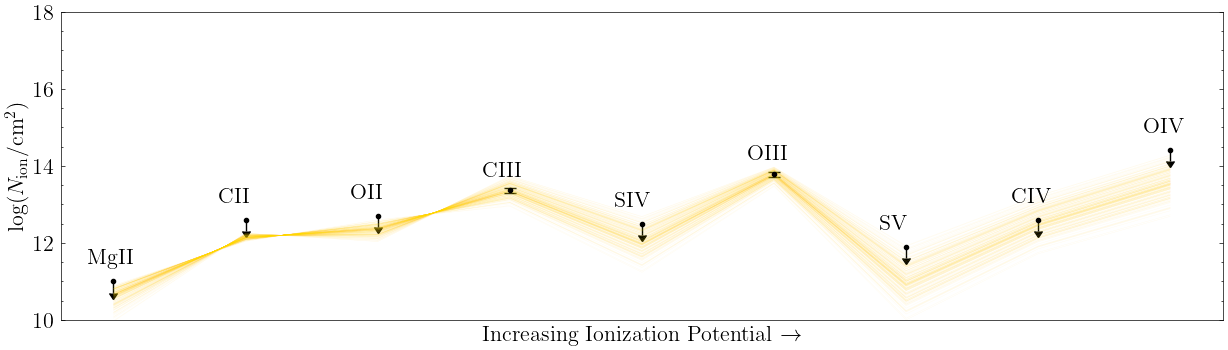

In [200]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp, {'C': np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='gold', lw=.2, alpha=.1)

In [201]:
get_cloud_size(16.67, -2.6, species_logN_interp)

7.050668427393466

# Multiphase solution

In [159]:
logN_dict = {#'HI':'16.67, -0.02, +0.02',
            #'CII':'<12.6',
            #'CIII':'13.36, -0.07, +0.07',
            #'CIV':'<12.6',
            #'NII':'<13.5',
            #'NIII':'<12.8',
            #'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'OVI':'14.17, -0.07, +0.07',
            'NeVIII':'<13.3',
            'MgII':'<11.0',
            #'AlIII':'<11.5',
            #'SiII':'<12.3',
            #'SiIII':'<12.3',
            #'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',
            'SVI':'<12.8',}
            #'FeII':'<11.4'}

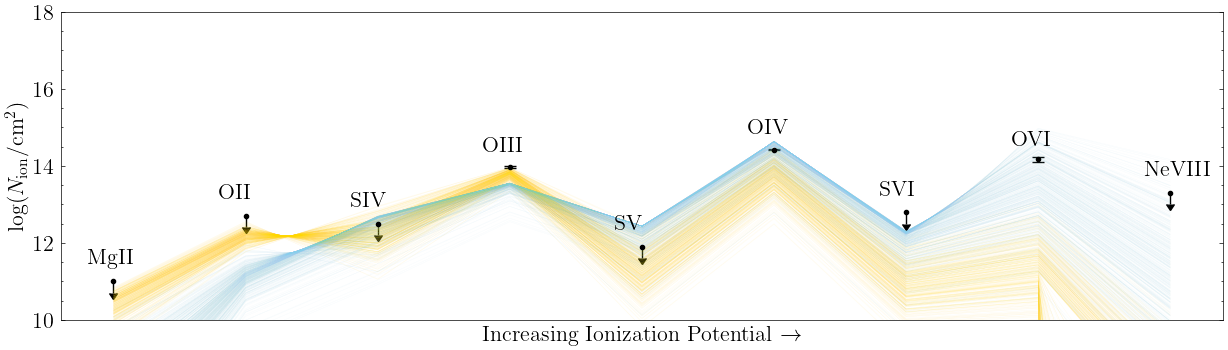

In [161]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(400):
    
    log_hdens_hi = np.random.normal(loc=-2.8, scale=0.2)
    log_hdens_lo = np.random.normal(loc=-3.7, scale=0.4)
    
    if log_hdens_min<log_hdens_hi<log_hdens_max and log_hdens_min<log_hdens_lo<log_hdens_max:
        
        logN_species_test_hi = np.array(predict_col_dens(logN_dict, 12, log_hdens_hi, 
                                             -3, species_logN_interp))+5.19

        logN_species_test_lo = np.array(predict_col_dens(logN_dict, 12, log_hdens_lo, 
                                             -3, species_logN_interp))+4.75

        logN_species_test = np.log10(10**logN_species_test_hi + 10**logN_species_test_lo)

        # Plot
        ax.plot(np.arange(len(logN_species_test_hi)), 
                np.array(logN_species_test_hi),
                color='gold', lw=.2, alpha=.1)

        # Plot
        ax.plot(np.arange(len(logN_species_test_lo)), 
                np.array(logN_species_test_lo),
                color='skyblue', lw=.2, alpha=.1)    

        #ax.plot(np.arange(len(logN_species_test)), 
        #        np.array(logN_species_test),
        #        color='lightcoral', lw=.2, alpha=.1)  

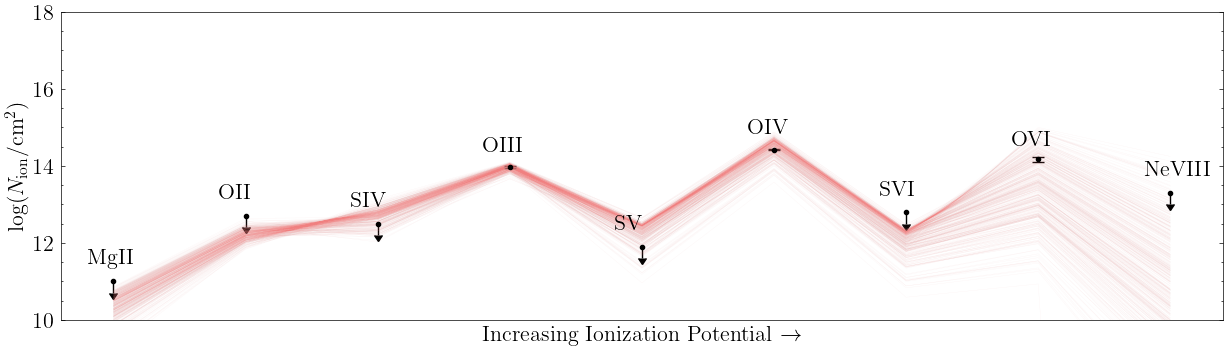

In [162]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(400):
    
    log_hdens_hi = np.random.normal(loc=-2.8, scale=0.2)
    log_hdens_lo = np.random.normal(loc=-3.7, scale=0.4)
    
    if log_hdens_min<log_hdens_hi<log_hdens_max and log_hdens_min<log_hdens_lo<log_hdens_max:
        
        logN_species_test_hi = np.array(predict_col_dens(logN_dict, 12, log_hdens_hi, 
                                             -3, species_logN_interp))+5.19

        logN_species_test_lo = np.array(predict_col_dens(logN_dict, 12, log_hdens_lo, 
                                             -3, species_logN_interp))+4.75

        logN_species_test = np.log10(10**logN_species_test_hi + 10**logN_species_test_lo)

        # Plot
        #ax.plot(np.arange(len(logN_species_test_hi)), 
        #        np.array(logN_species_test_hi),
        #        color='gold', lw=.2, alpha=.1)

        # Plot
        #ax.plot(np.arange(len(logN_species_test_lo)), 
        #        np.array(logN_species_test_lo),
        #        color='skyblue', lw=.2, alpha=.1)    

        ax.plot(np.arange(len(logN_species_test)), 
                np.array(logN_species_test),
                color='lightcoral', lw=.2, alpha=.1)  

# Constrain column densities and metallicities

In [165]:
#np.log10(10**15.20 + 10**14.80)

In [166]:
#-3+(5.36-(15.20-12)), -3+(5.21-(14.80-12))

Plot some solutions

In [202]:
logN_dict = {'HI':'16.67, -0.02, +0.02',
            #'CII':'<12.6',
            #'CIII':'13.36, -0.07, +0.07',
            #'CIV':'<12.6',
            #'NII':'<13.5',
            #'NIII':'<12.8',
            #'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'OVI':'<14.17',
            'NeVIII':'<13.3',
            'MgII':'<11.0',}
            #'AlIII':'<11.5',
            #'SiII':'<12.3',
            #'SiIII':'<12.3',
            #'SiIV':'<12.3',
            #'SIV':'<12.5',
            #'SV':'<11.9',
            #'SVI':'<12.8',}
            #'FeII':'<11.4'}

In [243]:
logN_HI_p1_test = 16.5
log_hdens_p1_test = -2.75
log_metals_p1_test = -2.3

logN_HI_p2_test = 14.6
log_hdens_p2_test = -3.7
log_metals_p2_test = -1

In [244]:
logN_species_test_p1 = (logN_HI_p1_test-12) + (log_metals_p1_test+3) + np.array(predict_col_dens(logN_dict, 
                                                                                                 12, 
                                                                                                 log_hdens_p1_test,
                                                                                                 -3, 
                                                                                 species_logN_interp))

logN_species_test_p2 = (logN_HI_p2_test-12) + (log_metals_p2_test+3) + np.array(predict_col_dens(logN_dict, 
                                                                                                 12, 
                                                                                                 log_hdens_p2_test,
                                                                                                 -3, 
                                                                                 species_logN_interp))

logN_species_test_p1[0] = logN_HI_p1_test
logN_species_test_p2[0] = logN_HI_p2_test

logN_species_test = np.log10(10**logN_species_test_p1 + 10**logN_species_test_p2)

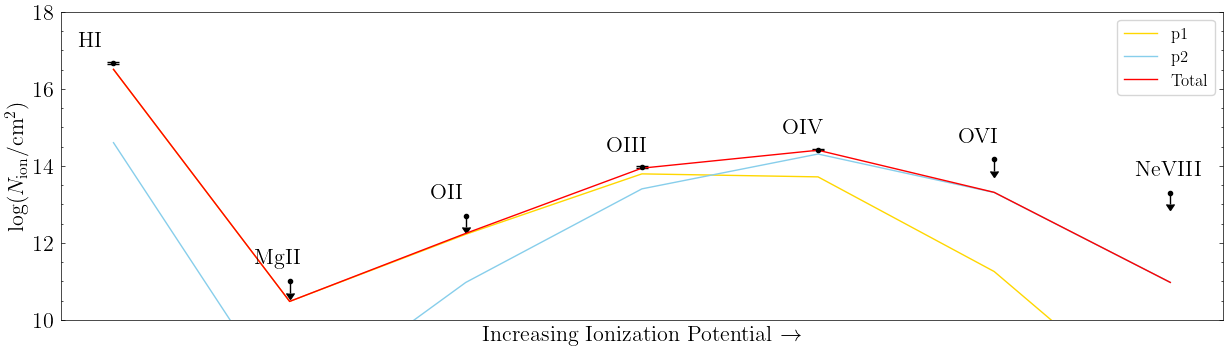

In [245]:
fig, ax = plot_column_densities_obs(logN_dict)

ax.plot(np.arange(len(logN_species_test)), logN_species_test_p1, color='gold', label='p1')
ax.plot(np.arange(len(logN_species_test)), logN_species_test_p2, color='skyblue', label='p2')
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='red', label='Total')

ax.legend()

Constrain stuff

In [246]:
def log_probability(params, logN_dict, 
                    log_hdens_p1, log_hdens_p2, 
                    non_solar_dict_p1,  non_solar_dict_p2, 
                    species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = log_prior_N_HI_metals(params, log_hdens_p1, log_hdens_p2, species_logN_interp)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_N_HI_metals(params, logN_dict,
                                  log_hdens_p1, log_hdens_p2,
                                  non_solar_dict_p1,  non_solar_dict_p2,
                                  species_logN_interp)

In [247]:
pos = np.array([logN_HI_p1_test, log_metals_p1_test,
                logN_HI_p2_test, log_metals_p2_test]) + 1e-5 * np.random.randn(500, 4)
nwalkers, ndim = pos.shape

In [248]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict, 
                                           log_hdens_p1_test, log_hdens_p2_test,
                                           {}, {},
                                           species_logN_interp)
)

In [249]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [09:42<00:00,  1.17s/it]


In [250]:
flat_samples_metals = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logN_HI_p1', 'log_metals_p1',
                                         'logN_HI_p2', 'log_metals_p2'])
flat_samples_metals.to_csv(savedir+'N_HI_metals.csv', index=False)

#flat_samples_metals = pd.read_csv(savedir+'N_HI_metals.csv')

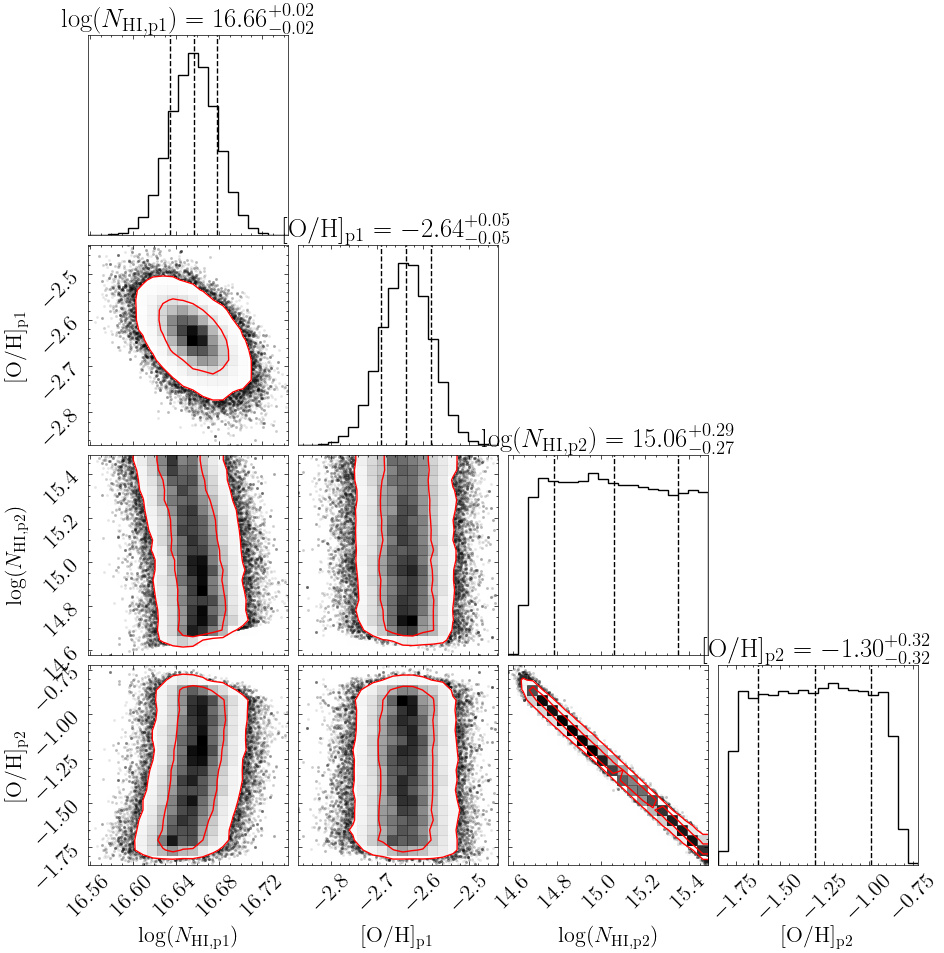

In [251]:
fig = corner.corner(
    flat_samples_metals, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(N_\mathrm{HI, p1})$', r'$[\mathrm{O/H}]_{\mathrm{p1}}$',
            r'$\log(N_\mathrm{HI, p2})$', r'$[\mathrm{O/H}]_{\mathrm{p2}}$',], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [252]:
#get_cloud_size(15.24, -3.0, species_logN_interp)

Get cloud sizes

In [253]:
l_hi_dist = np.array([get_cloud_size(logN_HI, 
                                  -2.75, 
                                  species_logN_interp) for logN_HI in flat_samples_metals['logN_HI_p1']])

In [254]:
l_lo_dist = np.array([get_cloud_size(logN_HI, 
                                  -3.7, 
                                  species_logN_interp) for logN_HI in flat_samples_metals['logN_HI_p2']])

Text(0, 0.5, 'Counts')

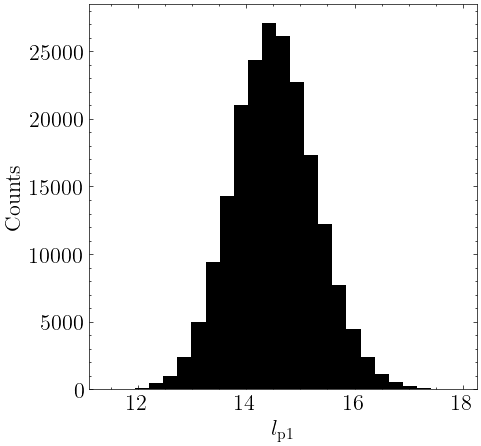

In [255]:
fig, ax = plt.subplots(1, figsize=(5,5))

ax.hist(l_hi_dist, bins=25)

ax.set_xlabel(r'$l_{\mathrm{p1}}$')
ax.set_ylabel('Counts')

Text(0, 0.5, 'Counts')

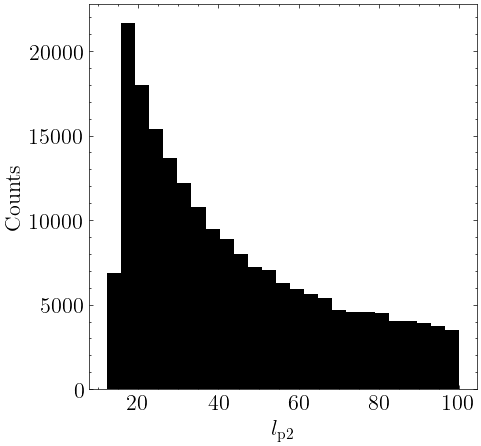

In [256]:
fig, ax = plt.subplots(1, figsize=(5,5))

ax.hist(l_lo_dist, bins=25)

ax.set_xlabel(r'$l_{\mathrm{p2}}$')
ax.set_ylabel('Counts')

Text(0, 0.5, '$l_{\\mathrm{p2}}$')

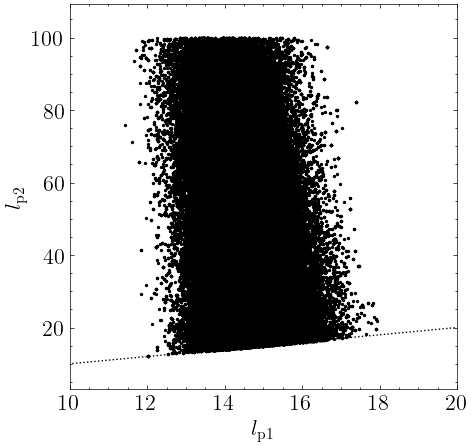

In [262]:
fig, ax = plt.subplots(1, figsize=(5,5))
ax.scatter(l_hi_dist, l_lo_dist, s=2)

lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]

# now plot both limits against eachother
ax.plot(lims, lims, linestyle=':')

ax.set_xlim(10, 20)

ax.set_xlabel(r'$l_{\mathrm{p1}}$')
ax.set_ylabel(r'$l_{\mathrm{p2}}$')

Overplot models

In [258]:
logN_dict = {'HI':'16.67, -0.02, +0.02',
            #'CII':'<12.6',
            #'CIII':'13.36, -0.07, +0.07',
            #'CIV':'<12.6',
            #'NII':'<13.5',
            #'NIII':'<12.8',
            #'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'OVI':'<14.17',
            'NeVIII':'<13.3',
            'MgII':'<11.0',}
            #'AlIII':'<11.5',
            #'SiII':'<12.3',
            #'SiIII':'<12.3',
            #'SiIV':'<12.3',
            #'SIV':'<12.5',
            #'SV':'<11.9',
            #'SVI':'<12.8',}
            #'FeII':'<11.4'}

In [259]:
sample_indices_metals = np.random.randint(low=0, high=len(flat_samples_metals), size=200)

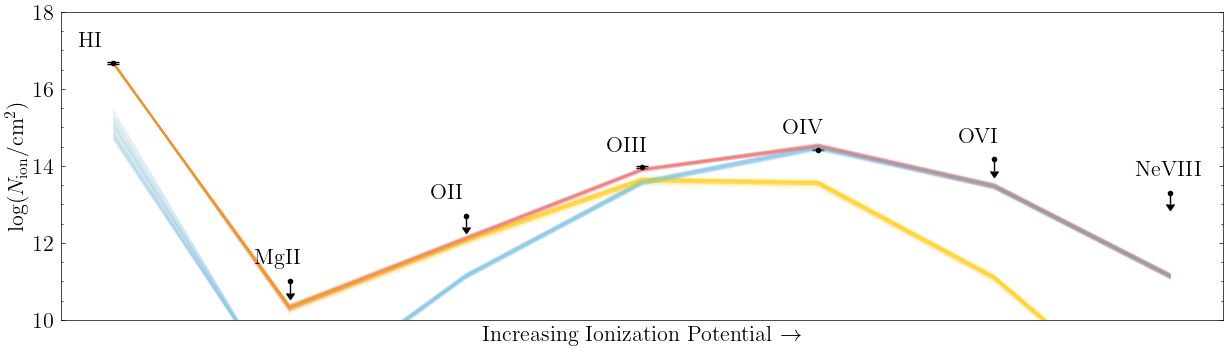

In [260]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_metals)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_metals.iloc[i]
    
    logN_HI_p1 = flat_samples_row['logN_HI_p1']
    logN_HI_p2 = flat_samples_row['logN_HI_p2']
    
    log_metals_p1 = flat_samples_row['log_metals_p1']
    log_metals_p2 = flat_samples_row['log_metals_p2']
    
    logN_species_test_hi = (logN_HI_p1-12)+(log_metals_p1+3)+np.array(predict_col_dens(logN_dict, 
                                                                                       12, -2.75, -3, 
                                                                                       species_logN_interp))
    
    logN_species_test_lo = (logN_HI_p2-12)+(log_metals_p2+3)+np.array(predict_col_dens(logN_dict, 
                                                                                       12, -3.7, -3, 
                                                                                       species_logN_interp))

    
    logN_species_test_hi[0] = logN_HI_p1
    logN_species_test_lo[0] = logN_HI_p2
    
    logN_species_test = np.log10(10**logN_species_test_hi + 10**logN_species_test_lo)
    
    # Plot
    ax.plot(np.arange(len(logN_species_test_hi)), 
            np.array(logN_species_test_hi),
            color='gold', lw=.2, alpha=.1)

    # Plot
    ax.plot(np.arange(len(logN_species_test_lo)), 
            np.array(logN_species_test_lo),
            color='skyblue', lw=.2, alpha=.1)    

    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test),
            color='lightcoral', lw=.2, alpha=.1)  

# Oxygen + Sulphur fit

In [22]:
# Assume solar abundance patterns throughout

def lambda_log_prior(params):
    
    # Only parameters being varied
    log_hdens, log_metals = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    if -4<log_hdens<-2 and log_metals_min<log_metals<log_metals_max:
        return 0.0
    return -np.inf

In [23]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    log_hdens, log_metals = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [23]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Isolate the ions

In [24]:
ions_oxy_sul = ['OII', 'OIII', 'SIV', 'SV']

In [25]:
logN_dict_oxy_sul = {ion: logN_dict[ion] for ion in ions_oxy_sul}

In [26]:
logN_dict_oxy_sul

{'OII': '<12.7', 'OIII': '13.97, -0.03, +0.03', 'SIV': '<12.5', 'SV': '<11.9'}

In [27]:
pos = np.array([log_hdens_test, log_metals_test]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [28]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_oxy_sul, species_logN_interp)
)

In [29]:
sampler.run_mcmc(pos, 500, progress=True)

100%|███████████████████████████████████| 500/500 [03:45<00:00,  2.22it/s]


State([[-3.16633538 -2.89865014]
 [-2.90034114 -2.64278262]
 [-2.85855067 -2.63164646]
 [-3.06435859 -2.80479807]
 [-2.98728218 -2.78271837]
 [-2.75624528 -2.50448861]
 [-2.5146421  -2.30986084]
 [-2.93070169 -2.70887972]
 [-2.87462179 -2.64525965]
 [-2.58367694 -2.30908783]
 [-2.95585245 -2.72425687]
 [-2.65556998 -2.37895531]
 [-3.07140262 -2.81756885]
 [-2.64293925 -2.39399169]
 [-2.77380539 -2.55847532]
 [-2.75489031 -2.49966184]
 [-2.96564    -2.70362622]
 [-2.52806595 -2.26946696]
 [-2.53744682 -2.31656605]
 [-3.12013463 -2.89687051]
 [-3.21025118 -2.99674339]
 [-3.0932282  -2.8550959 ]
 [-2.91423975 -2.66036765]
 [-3.14058118 -2.94726621]
 [-2.73851008 -2.45727052]
 [-2.98097122 -2.77848783]
 [-2.67312905 -2.40437967]
 [-3.18323779 -2.98078377]
 [-2.65196937 -2.43530301]
 [-2.97719266 -2.70492982]
 [-3.01926317 -2.73703201]
 [-2.68888957 -2.45843396]
 [-2.97378735 -2.79945643]
 [-2.96619869 -2.72758929]
 [-3.0744952  -2.86687182]
 [-2.68561288 -2.42951967]
 [-2.97711765 -2.73553

In [33]:
#flat_samples_oxy_sul = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens', 'log_metals'])
#flat_samples_oxy_sul.to_csv(savedir+'oxy_sul_solar_flat.csv', index=False)

flat_samples_oxy_sul = pd.read_csv(savedir+'oxy_sul_solar_flat.csv')

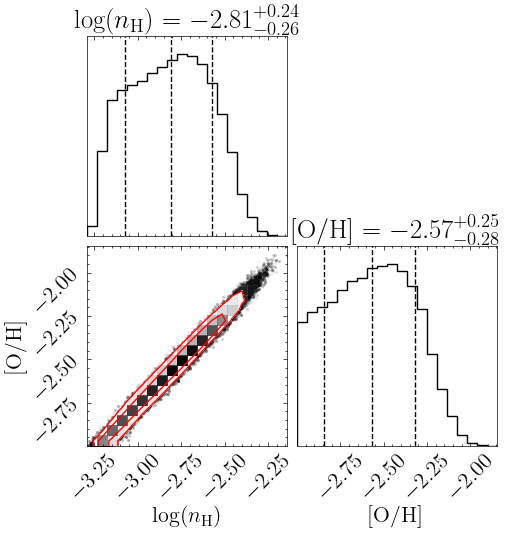

In [34]:
fig = corner.corner(
    flat_samples_oxy_sul.loc[:, ['log_hdens', 'log_metals']], quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [35]:
np.percentile(flat_samples_oxy_sul['log_metals'], 100*cdf_3sig)

-2.007894180745396

Now plot the best models

In [36]:
logN_dict = {'HI':'16.67, -0.02, +0.02',
            'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            'NII':'<13.5',
            'NIII':'<12.8',
            'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'OVI':'14.17, -0.07, +0.07',
            'NeVIII':'<13.3',
            'MgII':'<11.0',
            'AlIII':'<11.5',
            'SiII':'<12.3',
            'SiIII':'<12.3',
            'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',
            'SVI':'<12.8',
            'FeII':'<11.4'}

In [37]:
sample_indices_oxy_sul = np.random.randint(low=0, high=len(flat_samples_oxy_sul), size=200)

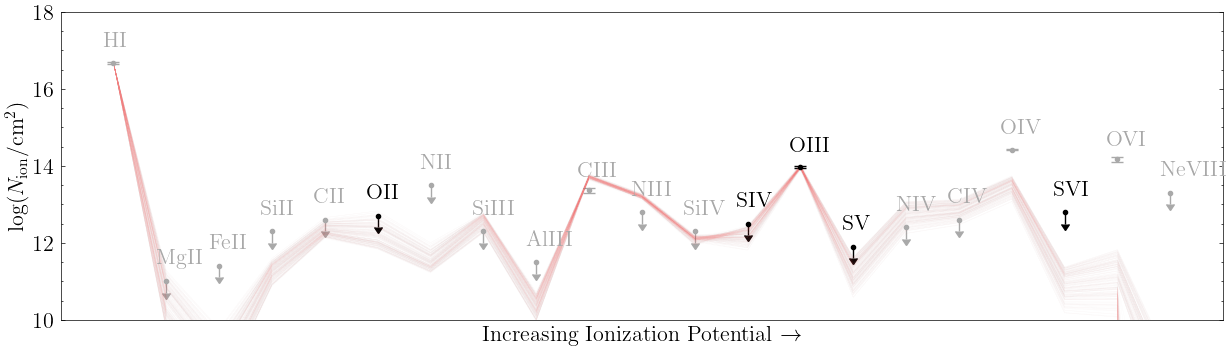

In [38]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'CII', 'CIII', 
                                                         'CIV', 'NII', 'NIII', 'NIV',
                                                         'NeVIII', 'MgII', 
                                                         'AlIII', 'SiII', 'SiIII', 'SiIV', 
                                                         'FeII', 'OIV', 'OVI'])

for i in range(len(sample_indices_oxy_sul)):
    
    idx = sample_indices_oxy_sul[i]
    flat_samples_row = flat_samples_oxy_sul.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

Plot the posterior for cloud size

In [39]:
#flat_samples_oxy_sul['logN_HII'] = [species_logN_interp['H+']([logN_HI_test,
#                                                            flat_samples_oxy_sul.iloc[i]['log_hdens'],
#                                                            flat_samples_oxy_sul.iloc[i]['log_metals']])[0]
#                                               for i in range(len(flat_samples_oxy_sul))]

In [40]:
#flat_samples_oxy_sul['cloud_size_kpc'] = ((10**logN_HI_test+10**flat_samples_oxy_sul['logN_HII'])/10**flat_samples_oxy_sul['log_hdens'])*3.24078e-19*1e-3

In [42]:
#flat_samples_oxy_sul.to_csv(savedir+'oxy_sul_solar_flat.csv', index=False)

In [43]:
l_med = np.median(flat_samples_oxy_sul['cloud_size_kpc'])
l_perc_16 = np.percentile(flat_samples_oxy_sul['cloud_size_kpc'],16)
l_perc_84 = np.percentile(flat_samples_oxy_sul['cloud_size_kpc'],84)

In [44]:
l_med, l_med-l_perc_16, l_perc_84-l_med

(20.384133684892436, 14.33732796106714, 57.75722326910622)

In [45]:
np.percentile(flat_samples_oxy_sul['cloud_size_kpc'],100*cdf_3sig)

199.0587337551194

Text(0, 0.5, 'Probability Density')

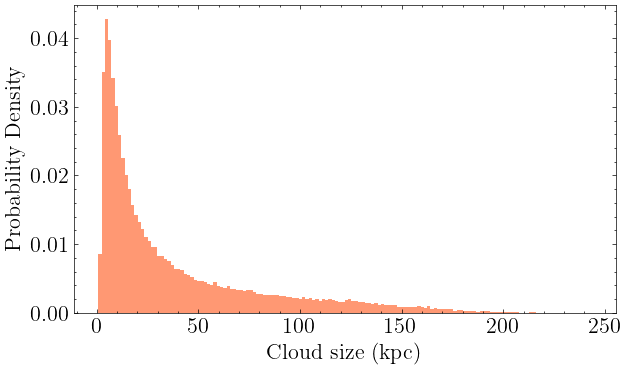

In [46]:
fig, ax = plt.subplots(1, figsize=(7,4))

ax.hist(flat_samples_oxy_sul['cloud_size_kpc'], bins=150, density=True, color='coral', alpha=.8)
#ax.axvline(l_med, linestyle=':', lw=2)
#ax.axvline(l_perc_16, linestyle=':', lw=2)
#ax.axvline(l_perc_84, linestyle=':', lw=2)

#ax.text(140, 0.03, s=r'$\log N_{\mathrm{HI}} = 16.64 \pm 0.01$')
#ax.text(140, 0.022, s=r'$l < 200 \ \mathrm{kpc}$')

ax.set_xlabel('Cloud size (kpc)')
ax.set_ylabel('Probability Density')

# Oxygen + Sulphur + Carbon

In [47]:
# Assume solar abundance patterns throughout

def lambda_log_prior(params):
    
    # Only parameters being varied
    log_hdens, log_metals, C_O = params
    
    # Get abundance for carbon
    C_H = log_metals + C_O
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    if -4<log_hdens<-2 and log_metals_min<log_metals<log_metals_max and log_metals_min<C_H<log_metals_max:
        return 0.0
    return -np.inf

In [48]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    log_hdens, log_metals, C_O = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {'C': C_O}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [49]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Isolate the ions

In [50]:
logN_dict = {'HI':'16.67, -0.02, +0.02',
            'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            'NII':'<13.5',
            'NIII':'<12.8',
            'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'OVI':'14.17, -0.07, +0.07',
            'NeVIII':'<13.3',
            'MgII':'<11.0',
            'AlIII':'<11.5',
            'SiII':'<12.3',
            'SiIII':'<12.3',
            'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',
            'SVI':'<12.8',
            'FeII':'<11.4'}

In [51]:
ions_oxy_sul_carb = ['OII', 'OIII', 'SIV', 'SV', 'CII', 'CIII']

In [52]:
logN_dict_oxy_sul_carb = {ion: logN_dict[ion] for ion in ions_oxy_sul_carb}

In [53]:
logN_dict_oxy_sul_carb

{'OII': '<12.7',
 'OIII': '13.97, -0.03, +0.03',
 'SIV': '<12.5',
 'SV': '<11.9',
 'CII': '<12.6',
 'CIII': '13.36, -0.07, +0.07'}

In [55]:
pos = np.array([log_hdens_test, log_metals_test, -0.4]) + 1e-4 * np.random.randn(500, 3)
nwalkers, ndim = pos.shape

In [56]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_oxy_sul_carb, species_logN_interp)
)

In [57]:
sampler.run_mcmc(pos, 500, progress=True)

  0%|                                             | 0/500 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████| 500/500 [05:06<00:00,  1.63it/s]


State([[-2.62645928 -2.35776275 -0.37128216]
 [-2.73889778 -2.46583243 -0.42102055]
 [-2.66978067 -2.46325373 -0.31388263]
 ...
 [-2.71446071 -2.47150373 -0.37069165]
 [-2.54831983 -2.27313387 -0.30409376]
 [-2.69363832 -2.46421867 -0.23439752]], log_prob=[ -4.43694269  -4.76891187  -5.21398205  -4.6119521   -4.5417973
  -4.24237301  -5.16564975  -5.2048928   -5.42267167  -4.34173053
  -4.86998771  -4.24419105  -6.45912227  -5.92731589  -6.15244457
  -4.22192637  -4.90691338  -5.64612228  -4.72911149  -6.64053613
  -4.47080332  -5.04078308  -4.50499358  -5.94931394  -5.03476246
  -5.55266312  -7.22845779  -4.96468072  -5.34927471  -4.69380296
  -4.23496973  -5.10443765  -8.36797348  -5.60581158  -5.87521415
  -4.53694945  -5.65081268  -4.60189085  -5.81922175  -6.34200358
  -6.78481284  -4.77107103  -5.02146637  -6.29493237  -5.57617629
  -4.34365082  -5.58719313  -4.83677471  -4.31774205  -4.79120555
  -4.52524961  -5.75126963  -4.22367043  -4.86649719  -4.39126682
  -4.28372006  -4.3

In [59]:
#flat_samples_oxy_sul_carb = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens', 'log_metals', 'C_O'])
#flat_samples_oxy_sul_carb.to_csv(savedir+'oxy_sul_carb_subsolar_flat.csv', index=False)

flat_samples_oxy_sul_carb = pd.read_csv(savedir+'oxy_sul_carb_subsolar_flat.csv')

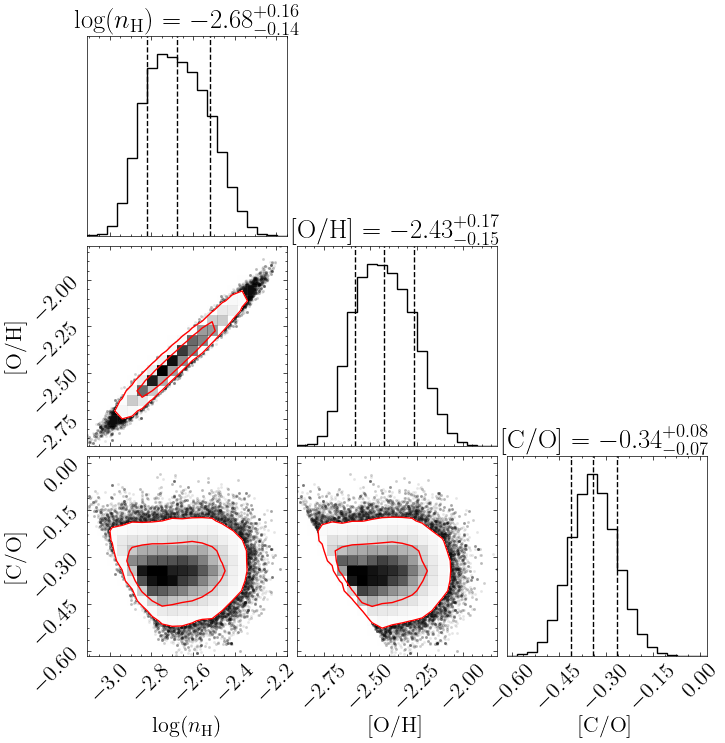

In [60]:
fig = corner.corner(
    flat_samples_oxy_sul_carb, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$', r'$[\mathrm{C/O}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Try out a new solution including sub-solar [C/O]

In [118]:
logN_HI_test = 16.67
log_hdens_test =  -3.25
log_metals_test = -2.54

In [119]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, log_metals_test, species_logN_interp,
                                    {'C':-0.45})

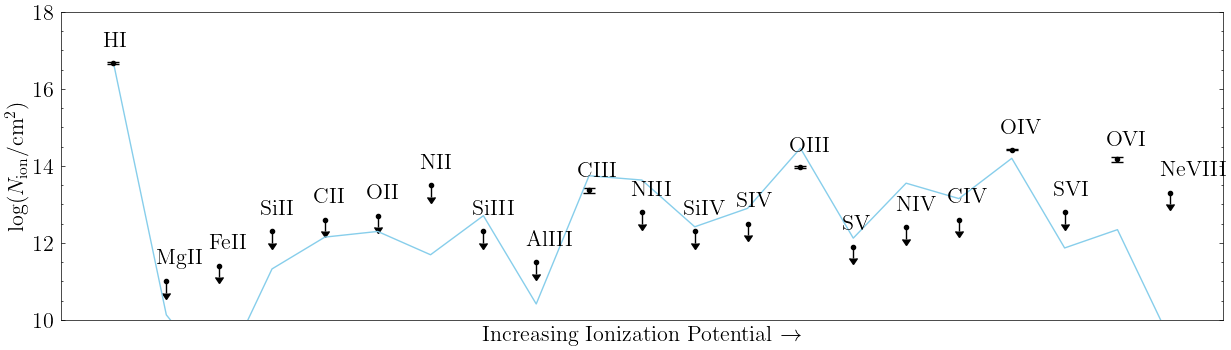

In [120]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

Now plot the best models

In [61]:
logN_dict = {'HI':'16.67, -0.02, +0.02',
            'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            'NII':'<13.5',
            'NIII':'<12.8',
            'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'OVI':'14.17, -0.07, +0.07',
            'NeVIII':'<13.3',
            'MgII':'<11.0',
            'AlIII':'<11.5',
            'SiII':'<12.3',
            'SiIII':'<12.3',
            'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',
            'SVI':'<12.8',
            'FeII':'<11.4'}

In [62]:
sample_indices_oxy_sul_carb = np.random.randint(low=0, high=len(flat_samples_oxy_sul_carb), size=200)

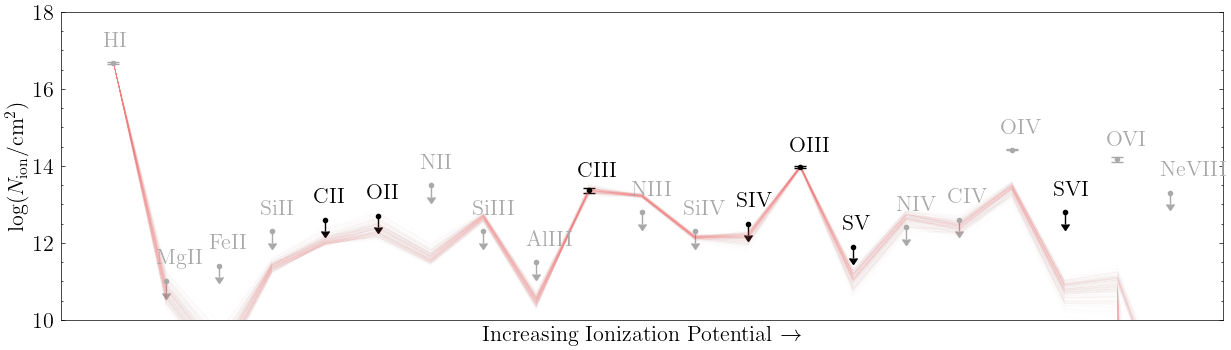

In [77]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'CIV', 'NII', 'NIII', 'NIV',
                                                         'NeVIII', 'MgII', 
                                                         'AlIII', 'SiII', 'SiIII', 'SiIV', 
                                                         'FeII', 'OIV', 'OVI'])

for i in range(len(sample_indices_oxy_sul_carb)):
    
    idx = sample_indices_oxy_sul_carb[i]
    flat_samples_row = flat_samples_oxy_sul_carb.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    C_O = flat_samples_row['C_O']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp, {'C': C_O})
    
    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

Plot the posterior for cloud size

In [64]:
#flat_samples_oxy_sul_carb['logN_HII'] = [species_logN_interp['H+']([logN_HI_test,
#                                                            flat_samples_oxy_sul_carb.iloc[i]['log_hdens'],
#                                                            flat_samples_oxy_sul_carb.iloc[i]['log_metals']])[0]
#                                               for i in range(len(flat_samples_oxy_sul_carb))]

In [65]:
#flat_samples_oxy_sul_carb['cloud_size_kpc'] = ((10**logN_HI_test+10**flat_samples_oxy_sul_carb['logN_HII'])/10**flat_samples_oxy_sul_carb['log_hdens'])*3.24078e-19*1e-3

In [67]:
#flat_samples_oxy_sul_carb.to_csv(savedir+'oxy_sul_carb_subsolar_flat.csv', index=False)

In [73]:
l_med = np.median(flat_samples_oxy_sul_carb['cloud_size_kpc'])
l_perc_16 = np.percentile(flat_samples_oxy_sul_carb['cloud_size_kpc'],16)
l_perc_84 = np.percentile(flat_samples_oxy_sul_carb['cloud_size_kpc'],84)

In [74]:
l_med, l_med-l_perc_16, l_perc_84-l_med

(10.351958198290964, 5.738431742689879, 11.203964842542964)

In [75]:
np.percentile(flat_samples_oxy_sul_carb['cloud_size_kpc'],100*cdf_3sig)

57.66707442182824

Text(0, 0.5, 'Probability Density')

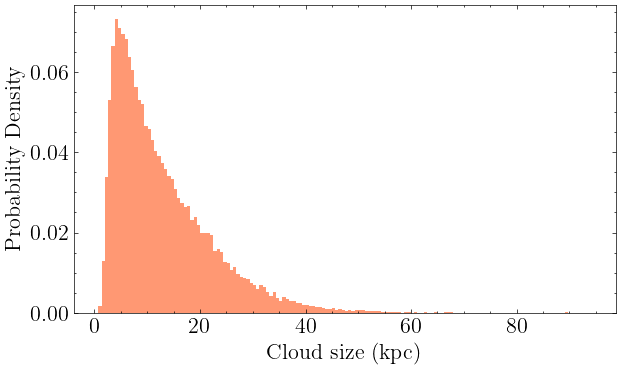

In [76]:
fig, ax = plt.subplots(1, figsize=(7,4))

ax.hist(flat_samples_oxy_sul_carb['cloud_size_kpc'], bins=150, density=True, color='coral', alpha=.8)
#ax.axvline(l_med, linestyle=':', lw=2)
#ax.axvline(l_perc_16, linestyle=':', lw=2)
#ax.axvline(l_perc_84, linestyle=':', lw=2)

#ax.text(140, 0.03, s=r'$\log N_{\mathrm{HI}} = 16.64 \pm 0.01$')
#ax.text(140, 0.022, s=r'$l < 200 \ \mathrm{kpc}$')

ax.set_xlabel('Cloud size (kpc)')
ax.set_ylabel('Probability Density')